<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1:
- Nombre de alumno 2:


### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/...../)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

1. Dado el rango de las variables, se utilizo un minmax scaler, para poder llevar a todas las variables al rango 0-1, y asi no afecte la diferencia de escalas en los modelos.

2. * No es un mal modelo, pero tampoco es un modelo bueno, considerando que de 5 diabeticos, uno no sera catalogado como tal, lo que represneta un riesgo de salud, mientras que de 4 predichos como diabeticos, 1 sera falso positivo, lo que puede llevar a que una persona no diabeitca use tratamientos que podrian destinarse a personas efectivamente diabeticas, ademas, de las predichas como sanas, habra una que sera diabetica, lo que al igual que recall, presentara un riesgo de salud.

   * El recall busca ver cuantos de los diabeticos, o no diabteicos, fueron catalogados correctamente, y la presicion, cuantos de los predichos como sanos o diabeticos, efectivamente lo son.

   * A partir de el modelo y adelantandonos al importance de mas adelante, podemos ver que existe la posibilidad de escoger mejores variables, debido al f1 que relativamente es bajo para el area de salud, y las varibales de baja importancia, se puede hacer un mejor feature selection, que podria llevar a mejores resultados

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
print(df.dtypes)


features = df.drop('Diabetes', axis=1)
target = df['Diabetes']


print(features.describe())

numerical_features = features.columns.tolist()

Age                     float64
Sex                     float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Stroke                  float64
HighBP                  float64
Diabetes                float64
dtype: object
                Age           Sex      HighChol     CholCheck           BMI  \
count  70692.000000  70692.000000  70692.000000  70692.000000  70692.000000   
mean       8.584055      0.456997      0.525703      0.975259     29.856985   
std        2.852153      0.498151      0.499342      0.155336      7.113954   
min        1.000000      0.000000      0.000000      0.000000     12.000000   
25%        7.00

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

n_vars = len(df.columns)
cols = 3
rows = (n_vars + cols - 1) // cols  # ceil división entera

# Creamos figura con subplots
fig = make_subplots(rows=rows, cols=cols, subplot_titles=df.columns)

# Agregamos un histograma por variable
for i, col_name in enumerate(df.columns):
    row = i // cols + 1
    col = i % cols + 1

    fig.add_trace(
        go.Histogram(x=df[col_name], marker_color='teal', opacity=0.75),
        row=row,
        col=col
    )

# Ajustes de layout
fig.update_layout(height=rows*300, width=1000, showlegend=False, title_text="Histogramas variables numéricas escaladas")

fig.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=1/3,
    random_state=42,
    stratify=target 
)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features)
    ],
    verbose_feature_names_out=False
)


preprocessor.set_output(transform='pandas')

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [10]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier( eval_metric='logloss', random_state=42))
])


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

2. Analizando los graficos de importancia por los diferentes metodos, vemos que estos no son compatibles, pues existen variables, como CholCheck, que son la mas importante en un metodo, pero son la con menos importancia en otro. Vemos que el metodo por peso se refiere a la cantidad de veces que una variable aparece en el arbol, mientras que gain calcula la importancia segun la ganancia promedio obtenida de las particiones a partir de esta feature, y cover la calcula a partir de la cantidad de muestras afectadas por las particiones de esta feature. Con esto dicho, vemos que las diferencias se pueden deber a que quizas una variable aparece poco en el arbol, pero son muchas las muestras afectadas por sus particiones, como es el caso de CholCheck, o se obtiene harta ganancia por las particiones, pero esta variable afecta a pocas muestras, o aparece una cantidad menor de veces que otras, como es el caso de HighChol.

3. Las importancias si son suficientes para obtener una interpretabilidad ya que debido a la forma que estan hechos los arboles, se forman decisiones en el que se pesa el efecto que tiene esa decision en la prediccion de la variable. Sin embargo, cuenta con una debilidad, y esta asociada al sesgo a ciertas variables, en el que el modelo es influido por variables numericas o con muchas categorias. También, otro problema que surge, es que dependiendo de la cantidad de arboles y variables que hayan tiene un efecto en los resultados y en los importance de las variables.

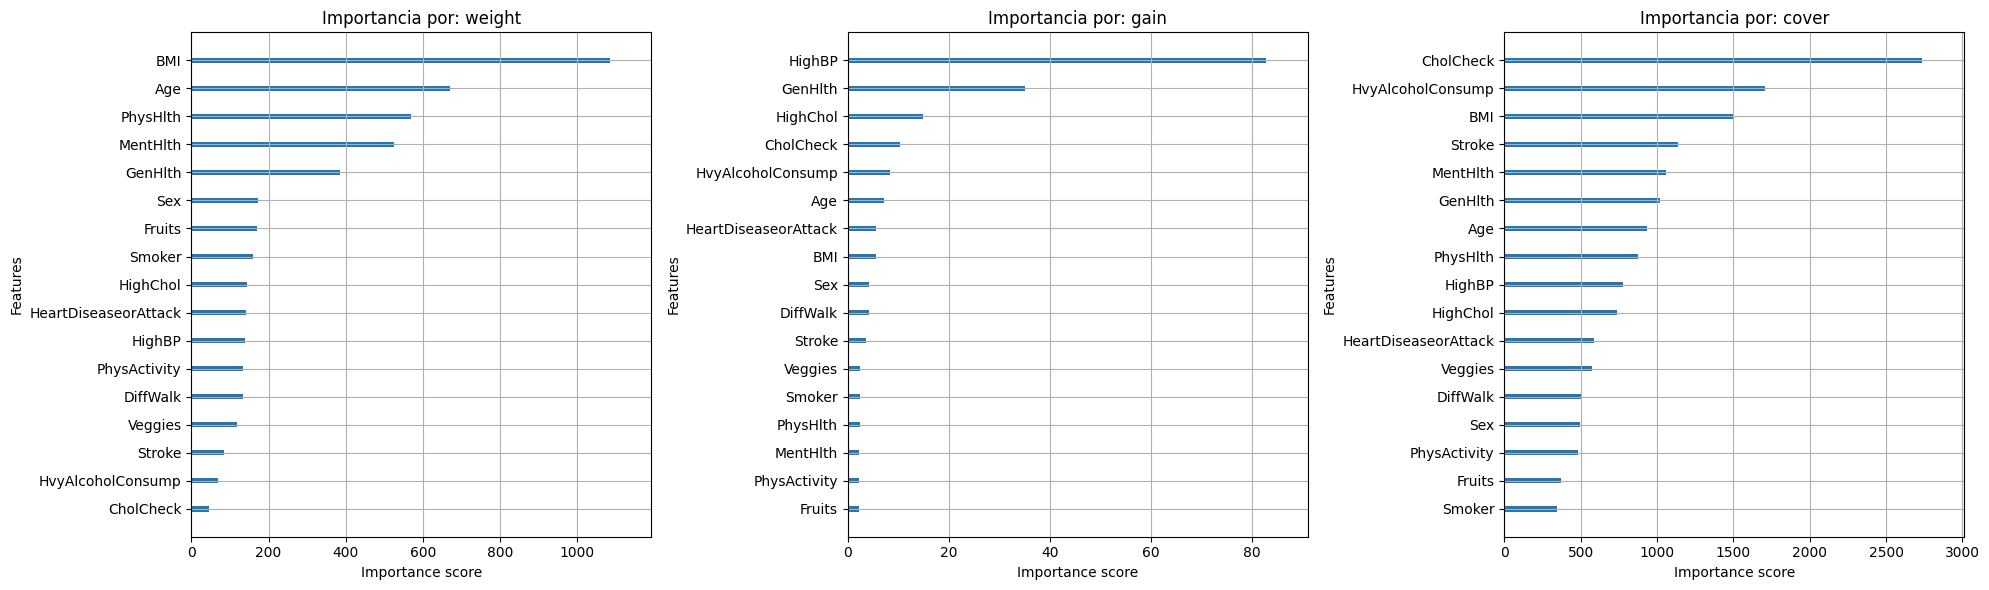

In [11]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

xgb_entrenado = pipeline.named_steps['model']

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

for i, importance_type in enumerate(['weight', 'gain', 'cover']):
    plot_importance(
        xgb_entrenado,
        importance_type=importance_type,
        ax=axs[i],
        show_values=False,
        title=f'Importancia por: {importance_type}'
    )

plt.tight_layout()
plt.show()

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

4.1 El modelo mide la importancia a medida que reduce el accuracy, es decir, al mantener las otras variables fijas, si esta variable baja el rendimiento del accuracy tiene una alta importancia para el modelo. 

4.2 Las 5 primeras son Age, Sex, HighChol, CholCheck y BMI. Las cuales tiene sentido ya que los problemas de salud aumentan con la edad, hay ciertas enfermedades que se presentan solo en ciertos géneros y finalmente las ultimas tres están relacionadas con porcentaje de grasas y malos hábitos, que están correlacionado con problemas cardiovasculares, diabetes y salud en general.

4.3 Aunque previamente hayamos visto las tres variables como si fuesen poco correlacionadas y que todas tengan una importancia por separada en los distintos modelos, a partir de la información de este feature importance, podemos ver que las 5 tienen sentido en torno a problemas de salud, y es mas confiable ya que no depende del orden y de los splits de los arboles. También, podemos ver el efecto de correlación con cholcheck y highchol.

4.4 Aquí se puede ver el efecto real de cada feature sobre el modelo, en vez de tener que estar interpretando en cada modelo. También, es mas precisa sin que se afecta por el tipo modelo y orden/split de los arboles. Y finalmente funciona con cualquier modelo, no limitandose con los arboles.

En cuanto a desventajas, se tienen que hacer muchas repeticiones lo que lleva a un alto costo computacional. En torno a correlaciones, puede afectar el importance de una variable, subestimandolo debido al efecto del otro. Y finalmente tiene resultados aleatorios, lo que lleva a la necesidad de las repeticiones y la necesidad de la desviación estándar para poder descartar variables que perjudican mucho.

In [12]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Ejecutar permutation importance con 30 repeticiones
result = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='accuracy'
)

# Convertir a DataFrame ordenado
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

# Mostrar tabla
print(perm_df)


                 feature  importance_mean  importance_std
0                    Age         0.027874        0.001587
1                    Sex         0.003169        0.000850
2               HighChol         0.011867        0.001400
3              CholCheck         0.003800        0.000411
4                    BMI         0.031069        0.002031
5                 Smoker        -0.000023        0.000507
6   HeartDiseaseorAttack         0.004545        0.000652
7           PhysActivity         0.000259        0.000604
8                 Fruits         0.000263        0.000777
9                Veggies         0.000552        0.000540
10     HvyAlcoholConsump         0.003262        0.000585
11               GenHlth         0.055675        0.001935
12              MentHlth         0.000412        0.000798
13              PhysHlth         0.002427        0.000998
14              DiffWalk         0.002420        0.000712
15                Stroke         0.001331        0.000397
16            

In [13]:
feature_names = xgb_entrenado.get_booster().feature_names
feature_names

['Age',
 'Sex',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Stroke',
 'HighBP']

In [ ]:
perm_df = perm_df.sort_values(by="importance_mean", ascending=False)
perm_df["importancestd%"] = np.where(
    perm_df["importance_mean"] != 0,
    (perm_df["importance_std"] / perm_df["importance_mean"].abs()) * 100,
    np.nan
)


## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

2. Los resultados obtenidos por los shap values, una matriz que tiene la forma de, en este caso, X_test_transformed, con esto, vemos que cada fila de los shaps values estan asociadas a una muestra de nuestro X_test, y los valores de dicha fila, es decir los shaps values asociados a esa muestra, son la importancia de cada feature en la prediccion que se hizo para esa muestra

3. Si, los shaps values positivos aumentan la posibilidad de ser diabetico, mientras que los negativos la disminuyen, en este caso, ya que la clase positiva es ser diabetico

In [14]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
import shap

In [15]:
X_test_transformed = pipeline.named_steps['preprocessing'].transform(X_test)


X_test_transformed.columns = xgb_entrenado.get_booster().feature_names


explainer = shap.Explainer(xgb_entrenado)


shap_values = explainer(X_test_transformed)

In [16]:
shap_values.values[:]

array([[ 0.04362907,  0.08186933,  0.20679691, ..., -0.06335934,
        -0.01408196,  0.49843606],
       [ 0.17948443, -0.09023592,  0.16698262, ..., -0.04646496,
         0.2025074 ,  0.34764293],
       [ 0.23022428, -0.0564572 ,  0.29458937, ...,  0.0121133 ,
        -0.01510411,  0.42437232],
       ...,
       [ 0.3285273 , -0.12203296, -0.41231176, ..., -0.02540579,
        -0.03226659,  0.43096936],
       [-1.5644661 , -0.03246335, -0.49780148, ..., -0.03917399,
        -0.02167204,  0.47200072],
       [-1.0838214 ,  0.02369169, -0.45542303, ..., -0.02818862,
        -0.01808009, -0.6070331 ]], dtype=float32)

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

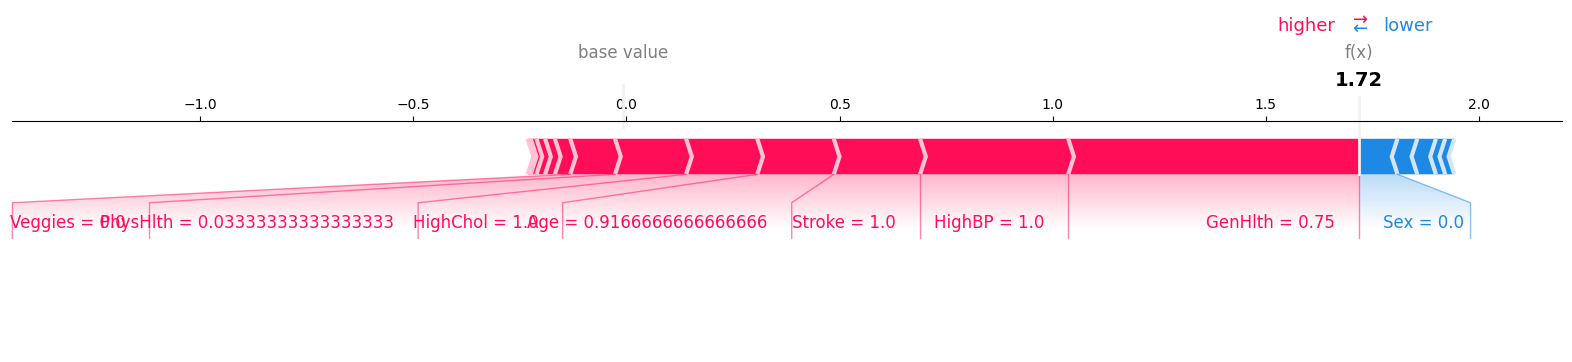

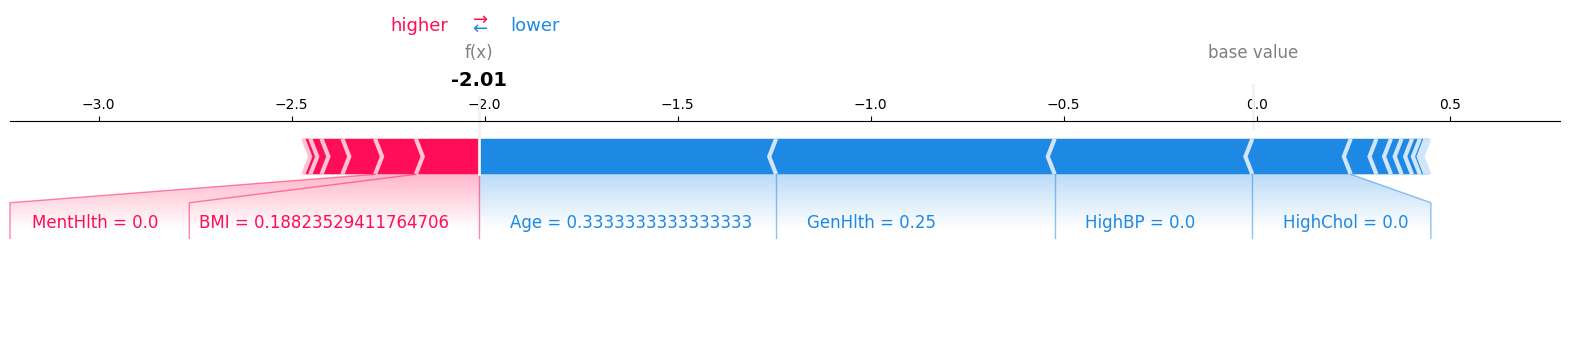

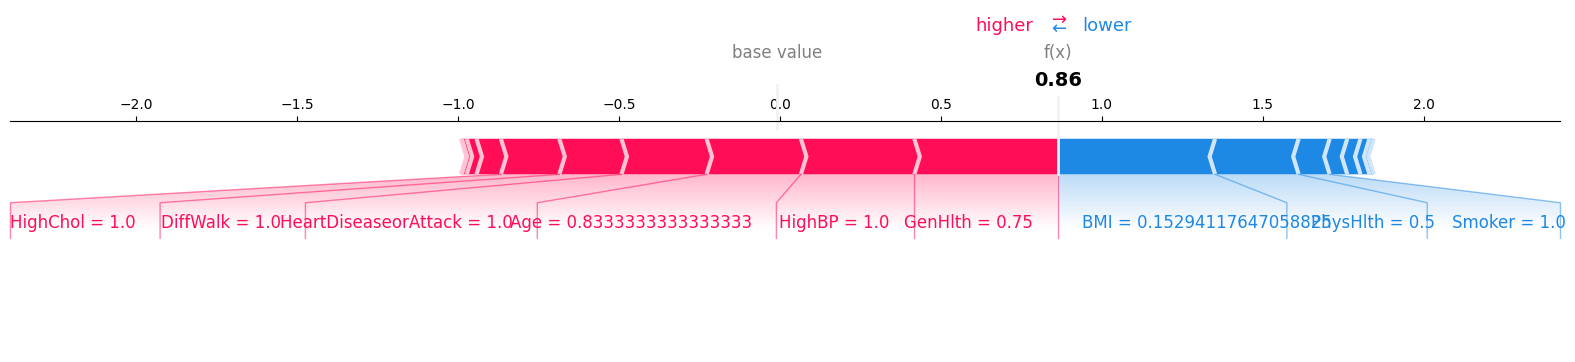

In [17]:
shap.initjs()

# Índices de las instancias a graficar
indices = [1, 9, 150]

with plt.style.context('default'):
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.facecolor'] = 'white'
    
    shap.force_plot(
        shap_values.base_values[1],
        shap_values.values[1],
        X_test_transformed.iloc[1],
        matplotlib=True
    )

with plt.style.context('default'):
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.facecolor'] = 'white'
    
    shap.force_plot(
        shap_values.base_values[9],
        shap_values.values[9],
        X_test_transformed.iloc[9],
        matplotlib=True
    )

with plt.style.context('default'):
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.facecolor'] = 'white'
    
    shap.force_plot(
        shap_values.base_values[150],
        shap_values.values[150],
        X_test_transformed.iloc[150],
        matplotlib=True
    )

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

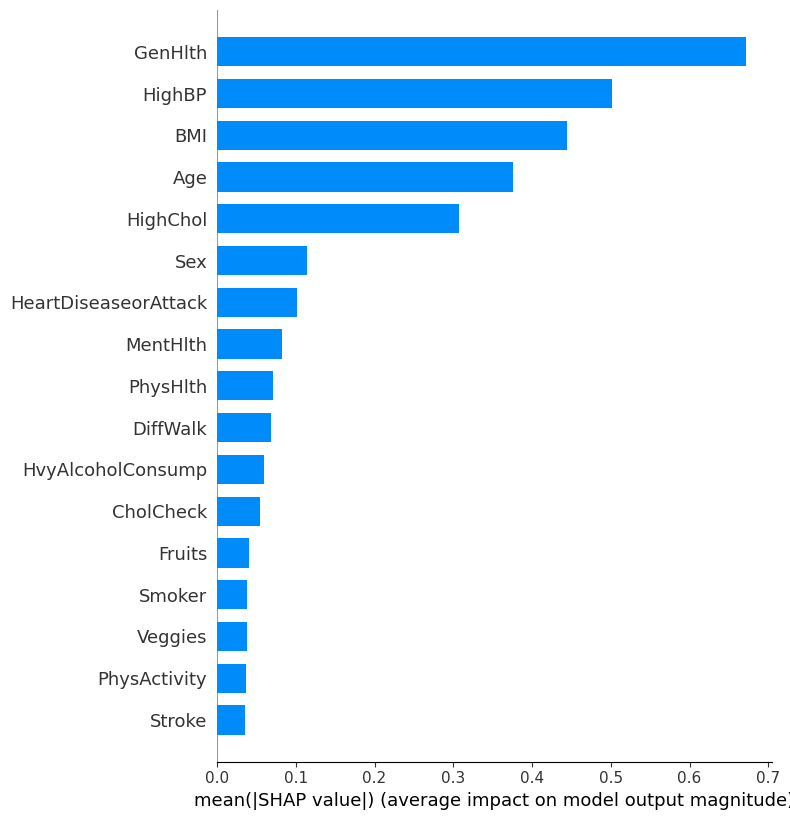

In [18]:
# Inserte código para generar gráficos de aporte global aquí
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    plot_type="bar"
)

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

De los diferentes scatter plots que hicimos, podemos notar que HighBp tiene una clara tendencia, en que el valor de 0 tienen valores shaps menores que el valor 1, lo cual ademas coincide con los valores predichos, ya que la mayoria de las muestras con valor 0 en esta variable son catalogados como no diabeticos, y los que son catalogados como diabeticos, son los que tienen en general valor mas alto de shap, mientras que para las muestras con valor 1 tienen valores mas altos de shap, y la mayoria de las muestras en este valor son catalogados como diabeticos, aunque sin embargo, existe mayor cantidad de no diabeticos en este valor, que de diabeticos para el valor 0, lo que sugiere que tener presion alta no es categorico para tener diabetes.

Respecto a la salud general, en donde un valor menor indica mejor salud, vemos que justamente al disminuir la salud general, o sensacion de esta (aumentar el valor de GenHlth), vemos que los valores de shaps comienzan a aumentar, asi como la cantidad de gente predicha como diabetica para los valores de esta feature, lo que indica que a medida que disminuye la salud, es mas probable ser catalogado como paciente diabetico.

Respecto al BMI, que es una variable mas discreta, vemos que a medida que este aumenta, los valores shaps aumentan casi de manera lineal al aumentar el valor de BMI, lo cual ademas, va de la mano con el aumento de pacientes diabeticos, lo cual nos permite concluir que a pacientes con mayor valor de BMI se les asignara mayor probabilidad de ser catalogados como diabeticos. Sin embargo, vemos que desde cierto punto, esta tendencia se rompe, pero admeas la cantidad de muestras disminuye, por lo cual es dificil sacar alguna conclusion de esto, ya que al ser pocas muestras, no se puede determinar una tendencia. (El punto en que esto pasa es desde el valor 0.5 aprox)

Respecto a la edad, vemos que a medida que aumenta la edad, el valor de shap tiende a aumentar, llevando la prediccion a ser catalogado como diabetico, aunque este aumento de los valores no es tan significativo como lo es con HighBp por ejemplo, pues ademas vemos que los rangos de los valores shaps son bastante altos, por lo que no es facil determinar el papel de la edad, o que tan relacionado esta con ser catalogado como diabetico, aunque si se puede notar que en general a edades mas bajas son menos los catalogados como diabeticos.

Respecto a HighChol, vemos que es una tendencia casi identica a HighBp, donde los rangos de valores Shaps de los 2 valores posibles no se intersectan, o lo hacen por muy poco, marcando una clara tendencia del impacto, o hacia donde empuja la prediccion cada valor posible, donde vemos que tener bajo colesterol empuja la prediccion hacia la negativa, es decir de ser sano, mientras que tener alto colesterol la empuja hacia ser diabetico, lo cual se condice con la distribucion de las predicciones para cada valor de HighChol



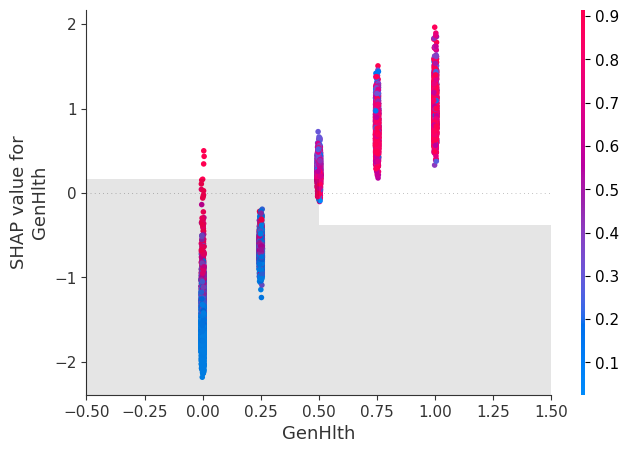

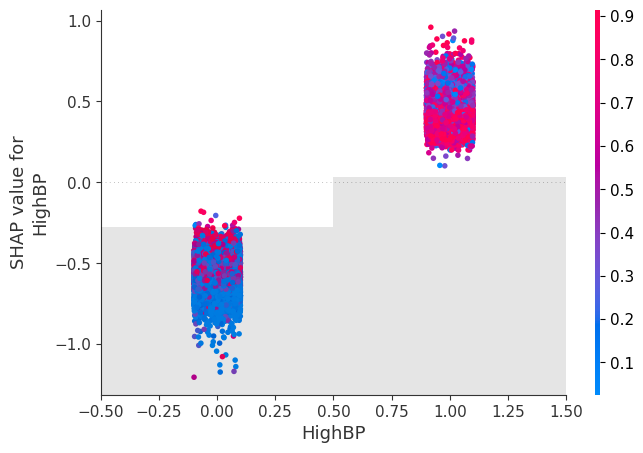

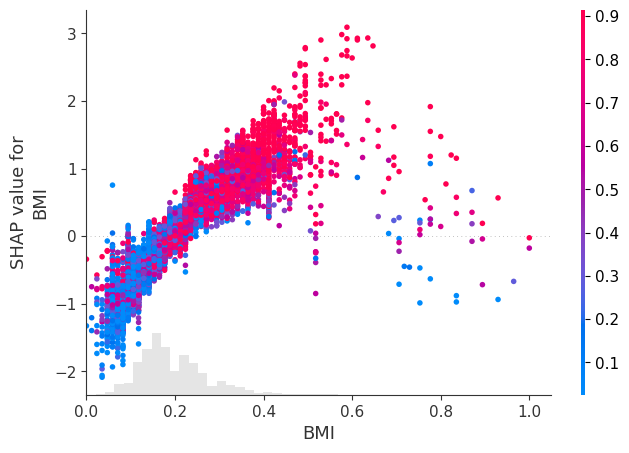

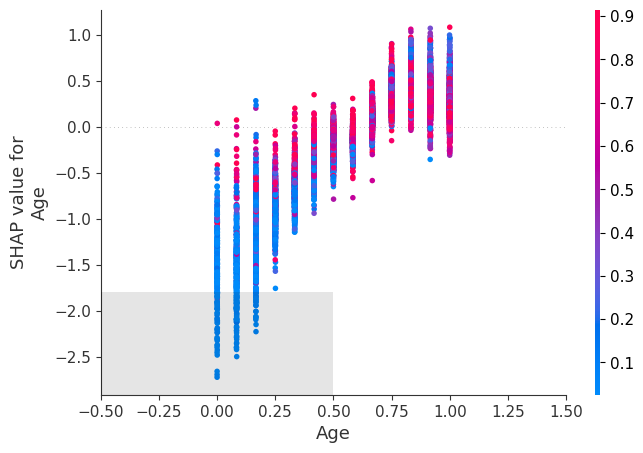

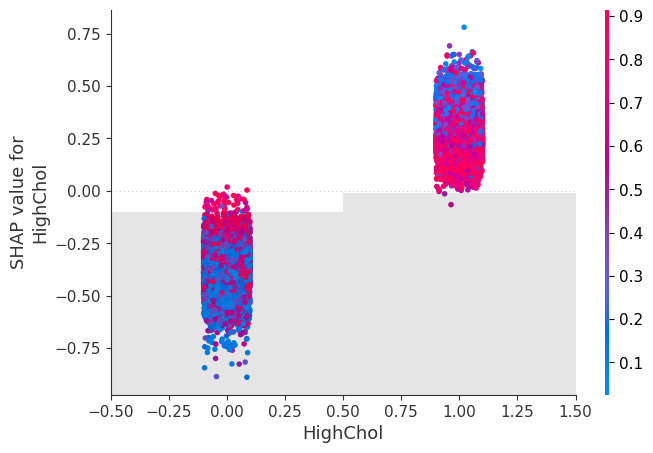

In [19]:
# Inserte código para generar gráficos de feature vs shap value aquí


mean_abs_shap = np.abs(shap_values.values).mean(axis=0)


top_5_idx = np.argsort(mean_abs_shap)[-5:][::-1]
top_5_features = X_test_transformed.columns[top_5_idx]

y_proba = pipeline.predict_proba(X_test)[:, 1]

import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np




import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Número de features a graficar

y_proba = pipeline.predict_proba(X_test)[:, 1]  # probabilidad clase positiva

shap.plots.scatter(shap_values[:, top_5_features[0]], color=y_proba, xmin=0)
shap.plots.scatter(shap_values[:, top_5_features[1]], color=y_proba, xmin=0)
shap.plots.scatter(shap_values[:, top_5_features[2]], color=y_proba, xmin=0)
shap.plots.scatter(shap_values[:, top_5_features[3]], color=y_proba, xmin=0)
shap.plots.scatter(shap_values[:, top_5_features[4]], color=y_proba, xmin=0)



### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [20]:
from alibi.explainers import AnchorTabular

In [ ]:
model_final = pipeline.named_steps['model']

print(model_final.classes_)

[0 1]


In [ ]:


feature_names = list(X_train.columns)
class_names = ['0', '1']

preprocessor = pipeline.named_steps['preprocessing']
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)



def predict_fn(x):
    return pipeline.named_steps['model'].predict(x)
feature_names = xgb_entrenado.get_booster().feature_names

explainer = AnchorTabular(
    predict_fn,
    feature_names=feature_names,
)


explainer.fit(X_train_preprocessed.to_numpy(), disc_perc=[25, 50, 75])








idx = 1000
# # explicar predicción idx 1000
print('----------------------------------')
print('----------------------------------')
print('inx = 1000')
explanation = explainer.explain(X_test_transformed.iloc[idx].to_numpy(), threshold=0.95)
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print('Precision: %.2f' % explanation.precision)
print('Coverage: %.2f' % explanation.coverage)
print('----------------------------------')
print('----------------------------------')
idx = 3001
# # explicar predicción idx 3001
print('inx = 3001')
explanation = explainer.explain(X_test_transformed.iloc[idx].to_numpy(), threshold=0.95)
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print('Precision: %.2f' % explanation.precision)
print('Coverage: %.2f' % explanation.coverage)
print('----------------------------------')
print('----------------------------------')
idx = 5751
# # explicar predicción idx 5751
print('inx = 5751')
explanation = explainer.explain(X_test_transformed.iloc[idx].to_numpy(), threshold=0.95)
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print('Precision: %.2f' % explanation.precision)
print('Coverage: %.2f' % explanation.coverage)
print('----------------------------------')
print('----------------------------------')

----------------------------------
----------------------------------
inx = 1000
Anchor: GenHlth > 0.25 AND Age > 0.67 AND BMI > 0.14
Precision: 0.96
Coverage: 0.21
----------------------------------
----------------------------------
inx = 3001
Anchor: GenHlth > 0.25 AND HighBP > 0.00 AND BMI > 0.14 AND Age > 0.67
Precision: 0.98
Coverage: 0.17
----------------------------------
----------------------------------
inx = 5751
Anchor: GenHlth > 0.50 AND HeartDiseaseorAttack > 0.00
Precision: 0.99
Coverage: 0.08
----------------------------------
----------------------------------


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>